# Análise Exploratória de Dados (EDA) — RenovAtlas

Este notebook explora os dados de vento e radiação solar usados na solução, junto com as
covariáveis de relevo (elevação) e distância à costa. O objetivo é entender as
distribuições, as relações entre as variáveis e a sazonalidade, antes da modelagem.

As bases são duas: NASA POWER (satélite) e INMET (estações no chão).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config

W, S = config.WIND, config.SOLAR
nasa = pd.read_csv(config.PROCESSED / "nasa_points_cov.csv")
inmet = pd.read_csv(config.PROCESSED / "inmet_points_cov.csv")
print("NASA:", nasa.shape, "| INMET:", inmet.shape)
nasa.head()

NASA: (80, 7) | INMET: (36, 11)


,lat,lon,WIND_SPEED,SOLAR_IRRAD,n_days,elev,dist_coast
0,-5.5,-34.5,7.074986,6.052839,13746,0.0,120.797359
1,-5.5,-35.0,7.263942,6.052839,13746,0.0,109.191823
2,-5.5,-35.5,5.859665,5.756744,13746,40.0,119.018092
3,-5.5,-36.0,5.810800,5.756744,13746,240.0,148.182886
4,-5.5,-36.5,5.810800,6.019273,13746,66.0,189.295544


## 1. Estatísticas descritivas

A tabela abaixo resume as variáveis na base NASA: velocidade do vento (m/s), radiação
solar (kWh/m2/dia), elevação (m) e distância à costa (km).

In [2]:
cols = [W, S, "elev", "dist_coast"]
nasa[cols].describe().round(2)

,WIND_SPEED,SOLAR_IRRAD,elev,dist_coast
count,80.00,80.00,80.00,80.00
mean,5.23,5.88,288.94,218.43
std,0.77,0.21,225.97,131.27
min,4.08,5.33,0.00,0.25
25%,4.68,5.80,86.25,110.52
50%,5.06,5.95,314.00,205.58
75%,5.72,6.03,466.25,321.67
max,7.26,6.18,744.00,462.21


In [3]:
inmet[cols].describe().round(2)

,WIND_SPEED,SOLAR_IRRAD,elev,dist_coast
count,36.00,36.00,36.00,36.00
mean,2.86,5.39,291.39,262.98
std,0.95,0.57,232.73,152.77
min,1.67,4.17,0.00,1.54
25%,2.33,5.20,118.75,138.08
50%,2.74,5.50,231.50,239.91
75%,3.10,5.83,436.75,390.68
max,6.81,6.20,840.00,551.32


Observa-se que a NASA apresenta vento médio mais alto que o INMET, o que e coerente
com a literatura: o satélite tende a superestimar o vento em relacao as estacoes no chao.
A radiacao fica em faixa parecida nas duas bases.

## 2. Distribuição das variáveis

Histogramas do vento e da radiação nas duas bases.

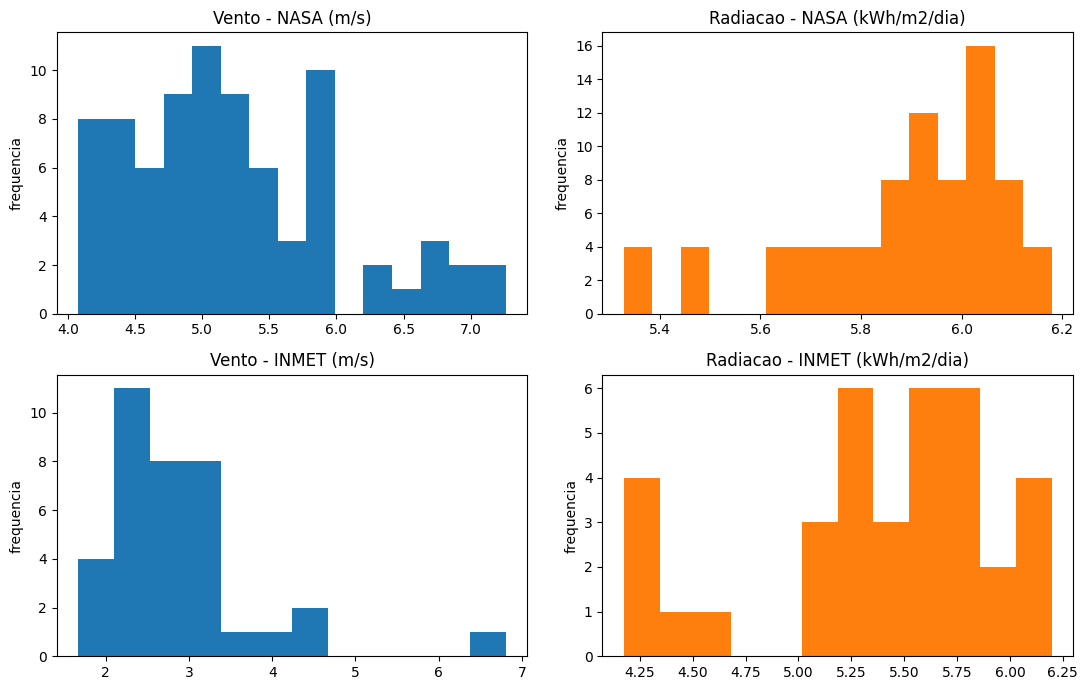

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0,0].hist(nasa[W], bins=15, color="#1f77b4"); ax[0,0].set_title("Vento - NASA (m/s)")
ax[0,1].hist(nasa[S], bins=15, color="#ff7f0e"); ax[0,1].set_title("Radiacao - NASA (kWh/m2/dia)")
ax[1,0].hist(inmet[W], bins=12, color="#1f77b4"); ax[1,0].set_title("Vento - INMET (m/s)")
ax[1,1].hist(inmet[S], bins=12, color="#ff7f0e"); ax[1,1].set_title("Radiacao - INMET (kWh/m2/dia)")
for a in ax.ravel(): a.set_ylabel("frequencia")
fig.tight_layout(); plt.show()

O vento da NASA concentra-se em valores mais altos e tem cauda para valores grandes
(pontos oceanicos). O vento do INMET e mais baixo. A radiacao e mais simetrica e estreita
nas duas bases, o que indica menor variabilidade espacial do recurso solar.

## 3. Relação com o relevo e a costa

O vento costuma depender da altitude e da proximidade do mar. Os graficos abaixo cruzam o
vento com a elevacao e com a distancia ate a costa (base NASA).

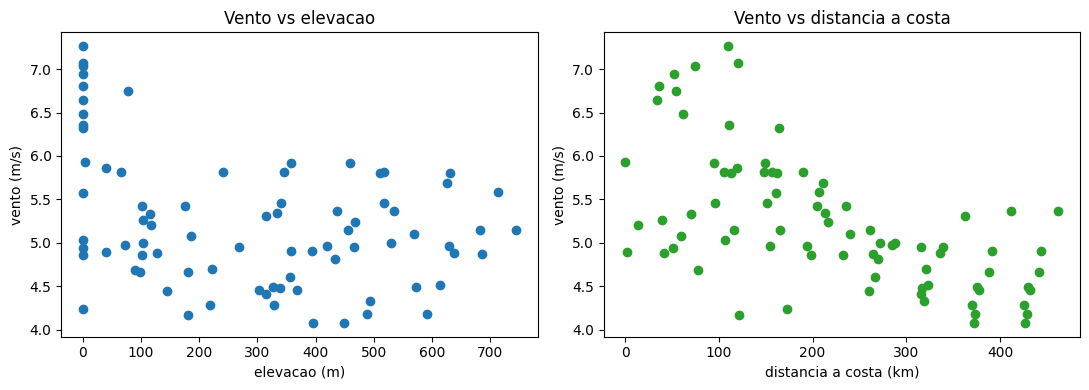

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(nasa["elev"], nasa[W], c="#1f77b4"); ax[0].set_xlabel("elevacao (m)"); ax[0].set_ylabel("vento (m/s)")
ax[0].set_title("Vento vs elevacao")
ax[1].scatter(nasa["dist_coast"], nasa[W], c="#2ca02c"); ax[1].set_xlabel("distancia a costa (km)"); ax[1].set_ylabel("vento (m/s)")
ax[1].set_title("Vento vs distancia a costa")
fig.tight_layout(); plt.show()

Ha uma tendencia de o vento variar com a elevacao e com a distancia a costa, o que
justifica testar essas covariaveis nos modelos de aprendizado de maquina. A relacao nao e
perfeitamente linear, indicando que modelos nao lineares podem ajudar.

## 4. Correlações

Matriz de correlacao entre as variaveis na base NASA.

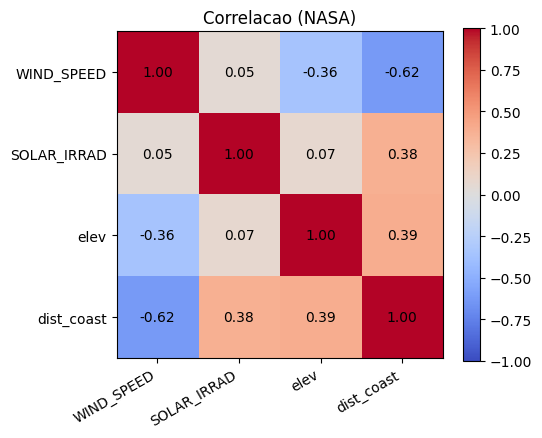

In [6]:
corr = nasa[cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=30, ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, "%.2f" % corr.iloc[i, j], ha="center", va="center")
plt.colorbar(im); ax.set_title("Correlacao (NASA)")
fig.tight_layout(); plt.show()

O vento e a radiacao tem correlacao fraca entre si, o que e bom para geracao hibrida
(as fontes nao sao redundantes). A elevacao e a distancia a costa mostram relacao com o
vento, reforcando seu uso como covariaveis.

## 5. Sazonalidade (ciclo mensal)

Media de cada mes do ano para um ponto central da Paraiba (base NASA), mostrando como
vento e radiacao variam ao longo do ano.

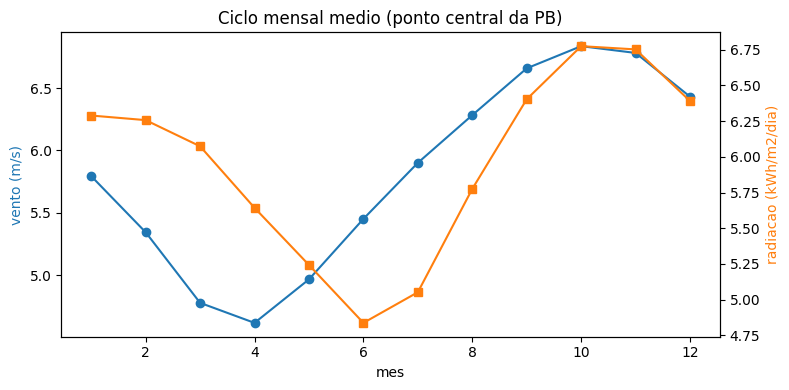

In [7]:
import glob
f = sorted(glob.glob(str(config.RAW / "nasa" / "nasa_-7.00_-36.50.csv")))
d = pd.read_csv(f[0], parse_dates=["date"]) if f else pd.read_csv(sorted(glob.glob(str(config.RAW/'nasa'/'nasa_*.csv')))[40], parse_dates=["date"])
m = d["date"].dt.month
mw = d.groupby(m)["WS10M"].mean()
ms = d.groupby(m)["ALLSKY_SFC_SW_DWN"].mean()
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(mw.index, mw.values, "-o", color="#1f77b4", label="vento (m/s)")
ax1.set_xlabel("mes"); ax1.set_ylabel("vento (m/s)", color="#1f77b4")
ax2 = ax1.twinx()
ax2.plot(ms.index, ms.values, "-s", color="#ff7f0e", label="radiacao (kWh/m2/dia)")
ax2.set_ylabel("radiacao (kWh/m2/dia)", color="#ff7f0e")
ax1.set_title("Ciclo mensal medio (ponto central da PB)")
fig.tight_layout(); plt.show()

O vento e a radiacao tem picos em meses diferentes do ano, ou seja, ha um grau de
complementaridade temporal. Esse comportamento motiva a contribuicao do projeto, que
inclui um indice de complementaridade no calculo do potencial de geracao hibrida.

## Conclusao da EDA

Os dados mostram que: o vento da NASA e mais alto que o do INMET; a radiacao varia pouco
no espaco; o vento se relaciona com relevo e costa (covariaveis uteis); vento e radiacao
sao pouco correlacionados e tem picos sazonais distintos. Esses achados orientam a escolha
de modelos nao lineares e o uso da complementaridade temporal no indice final.